In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from src.parser import cargar_todos

# Configuracion visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Carga
facturas = cargar_todos('../data/raw')
print(f"Facturas cargadas: {len(facturas)}")

Facturas cargadas: 68514


In [2]:
registros = []
for f in facturas:
    for item in f.items:
        registros.append({
            'factura': f.numero,
            'fecha': f.fecha,
            'dia_semana': f.dia_semana,
            'producto': item.producto,
            'cantidad': item.cantidad,
            'precio_unitario': item.precio_unitario,
            'subtotal': item.subtotal
        })

df = pd.DataFrame(registros)
df['fecha'] = pd.to_datetime(df['fecha'])
print(f"Total line-items: {len(df)}")
df.head()

Total line-items: 147413


,factura,fecha,dia_semana,producto,cantidad,precio_unitario,subtotal
0,23102,2024-03-10,domingo,BRISA LIMON-MANZANA 600ML,1.0,2521.01,2521.0
1,23102,2024-03-10,domingo,TIC TAC 16GR,1.0,1848.74,1849.0
2,49554,2024-03-10,domingo,VIVE 100 LITRO,1.0,2941.18,2941.0
3,49554,2024-03-10,domingo,LUCKY GIN X 10,1.0,4873.95,4874.0
4,49555,2024-03-10,domingo,CRISTAL ALOE 330 ML,1.0,2184.87,2185.0


In [3]:
total_registros = len(df)
total_facturas = df['factura'].nunique()
items_por_factura = df.groupby('factura')['producto'].count()

print("=" * 45)
print("GENERALIDADES DEL CONJUNTO DE DATOS")
print("=" * 45)
print(f"Total registros (line-items): {total_registros:,}")
print(f"Total facturas:               {total_facturas:,}")
print(f"Promedio items por factura:   {items_por_factura.mean():.2f}")
print(f"Maximo items en una factura:  {items_por_factura.max()}")
print(f"Minimo items en una factura:  {items_por_factura.min()}")
print(f"Rango de fechas:              {df['fecha'].min().date()} -> {df['fecha'].max().date()}")
print(f"Dias de la semana presentes:  {sorted(df['dia_semana'].unique())}")

GENERALIDADES DEL CONJUNTO DE DATOS
Total registros (line-items): 147,413
Total facturas:               16,415
Promedio items por factura:   8.98
Maximo items en una factura:  264
Minimo items en una factura:  1
Rango de fechas:              2024-03-09 -> 2024-04-06
Dias de la semana presentes:  ['domingo', 'jueves', 'lunes', 'martes', 'miercoles', 'sabado', 'viernes']


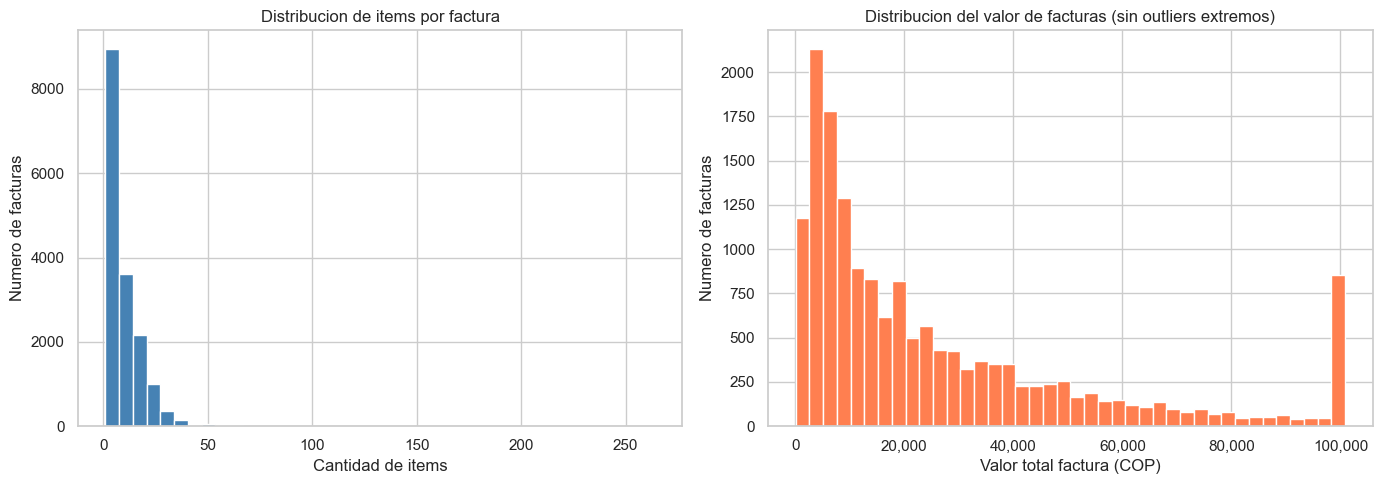

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma cantidad de items por factura
items_por_factura.plot(kind='hist', bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion de items por factura')
axes[0].set_xlabel('Cantidad de items')
axes[0].set_ylabel('Numero de facturas')

# Distribucion del subtotal por factura
total_por_factura = df.groupby('factura')['subtotal'].sum()
total_por_factura.clip(upper=total_por_factura.quantile(0.95)).plot(
    kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Distribucion del valor de facturas (sin outliers extremos)')
axes[1].set_xlabel('Valor total factura (COP)')
axes[1].set_ylabel('Numero de facturas')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../output/dist_items_y_valor.png', dpi=150)
plt.show()

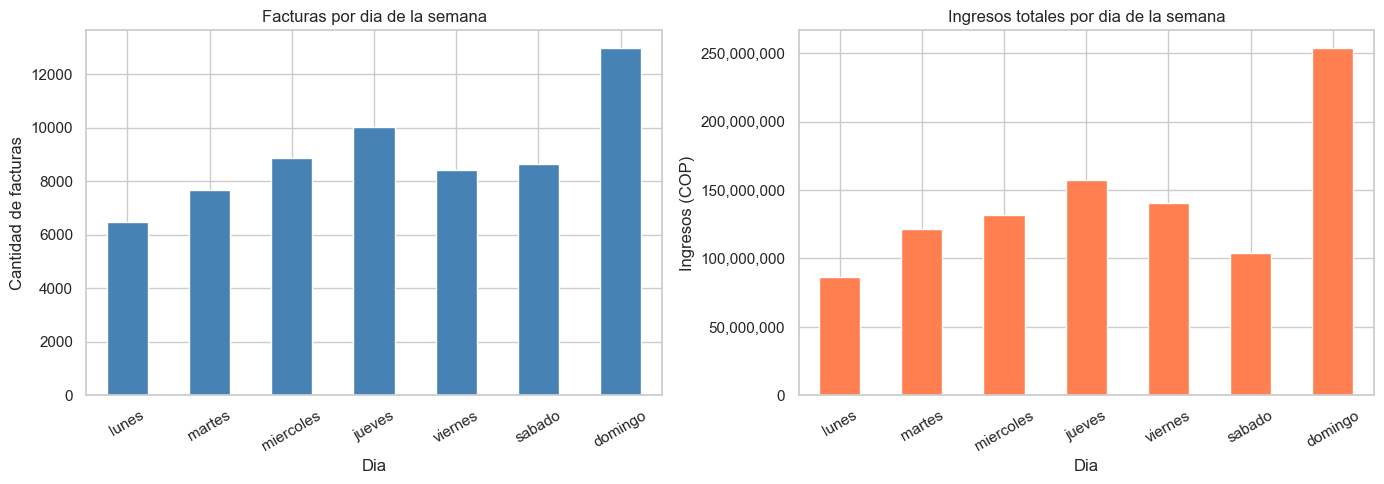

In [5]:
orden_dias = ['lunes', 'martes', 'miercoles', 'jueves', 'viernes', 'sabado', 'domingo']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Facturas por dia
facturas_dia = df.groupby('dia_semana')['factura'].nunique().reindex(orden_dias)
facturas_dia.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Facturas por dia de la semana')
axes[0].set_xlabel('Dia')
axes[0].set_ylabel('Cantidad de facturas')
axes[0].tick_params(axis='x', rotation=30)

# Ingresos por dia
ingresos_dia = df.groupby('dia_semana')['subtotal'].sum().reindex(orden_dias)
ingresos_dia.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Ingresos totales por dia de la semana')
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Ingresos (COP)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../output/compras_por_dia.png', dpi=150)
plt.show()

TOP 10 PRODUCTOS MAS VENDIDOS (cantidad total)
producto
EMPANADAS                                                                                                                                                                                                                                                         21099.0
DESECHABLE X UND                                                                                                                                                                                                                                                  8419.0
CERVEZA  AGUILA ORIGINAL 355ML                                                                                                                                                                                                                                     7960.0
CERVEZA POKER  355ML                                                                                                                              

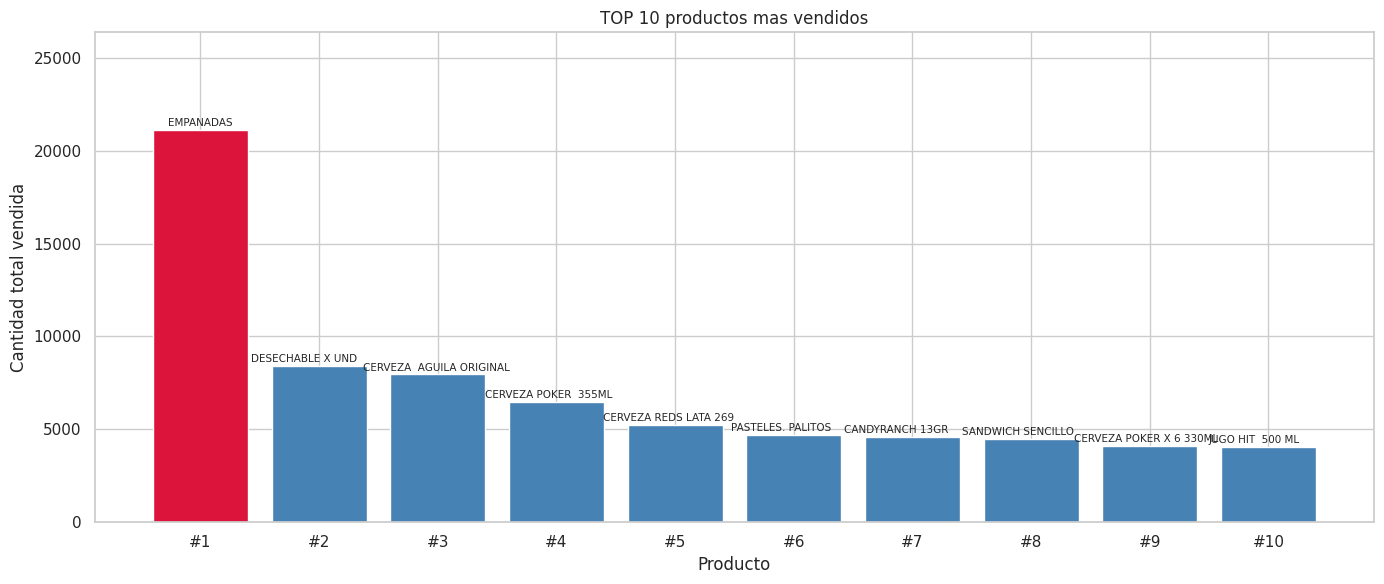

In [8]:
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Producto mas vendido general
top_general = (df.groupby('producto')['cantidad']
               .sum()
               .sort_values(ascending=False))

print("TOP 10 PRODUCTOS MAS VENDIDOS (cantidad total)")
print("=" * 50)
print(top_general.head(10).to_string())

# Grafica TOP 10
fig, ax = plt.subplots(figsize=(14, 6))
top10 = top_general.head(10).copy()

# Etiquetas cortas para el eje X
etiquetas_cortas = [f"#{i+1}" for i in range(len(top10))]
colores = ['crimson'] + ['steelblue'] * 9

bars = ax.bar(etiquetas_cortas, top10.values, color=colores, edgecolor='white')

# Anotar nombre completo encima de cada barra
for bar, nombre in zip(bars, top10.index):
    nombre_limpio = nombre.strip()[:25]
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            nombre_limpio,
            ha='center', va='bottom', fontsize=7.5, rotation=0)

ax.set_title('TOP 10 productos mas vendidos')
ax.set_xlabel('Producto')
ax.set_ylabel('Cantidad total vendida')
ax.set_ylim(0, top10.values.max() * 1.25)
plt.tight_layout()
plt.savefig('../output/top10_productos.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Producto menos vendido
menos_vendido = top_general.tail(1)
nombre_menos = menos_vendido.index[0]
print(f"Producto menos vendido: {nombre_menos}")
print(f"Cantidad total vendida: {int(menos_vendido.values[0])}")

# En cuantas facturas aparece
facturas_con_producto = df[df['producto'] == nombre_menos]['factura'].unique()
print(f"Aparece en {len(facturas_con_producto)} factura(s)")

# Se vendio solo o acompanado?
for fac in facturas_con_producto:
    items_fac = df[df['factura'] == fac]['producto'].tolist()
    print(f"\nFactura {fac}: {len(items_fac)} item(s)")
    for p in items_fac:
        print(f"  - {p}")

Producto menos vendido: VINO ESTORIL 750ML
Cantidad total vendida: 1
Aparece en 1 factura(s)

Factura 56836: 2 item(s)
  - VINO ESTORIL 750ML
  - COCA COLA FLEXI 400 ML


In [10]:
# Extraer hora desde SECUEN (es un numero de secuencia, no hora real)
# Usamos la fecha del archivo y agrupamos por dia para simular hora con SECUEN
# Como no hay campo hora en el DBF, aproximamos hora por bloques de SECUEN por dia

# Alternativa real: agrupar por bloques del numero de factura por dia
# Dividimos el rango de facturas de cada dia en 12 bloques de 2 horas (8am-8pm)

def asignar_bloque_hora(factura_num, min_fac, max_fac):
    bloques = 12
    rango = max_fac - min_fac if max_fac != min_fac else 1
    bloque = int((factura_num - min_fac) / rango * bloques)
    hora = 8 + min(bloque, bloques - 1) * 1
    return f"{hora:02d}:00"

rangos = df.groupby('fecha')['factura'].agg(['min', 'max'])
df = df.join(rangos, on='fecha')
df['hora_aprox'] = df.apply(
    lambda r: asignar_bloque_hora(r['factura'], r['min'], r['max']), axis=1
)
df.drop(columns=['min', 'max'], inplace=True)

# Producto mas vendido por hora
top_por_hora = (df.groupby(['hora_aprox', 'producto'])['cantidad']
                .sum()
                .reset_index()
                .sort_values(['hora_aprox', 'cantidad'], ascending=[True, False]))

top1_por_hora = top_por_hora.groupby('hora_aprox').first().reset_index()
print("PRODUCTO MAS VENDIDO POR BLOQUE HORARIO")
print("=" * 50)
print(top1_por_hora[['hora_aprox', 'producto', 'cantidad']].to_string(index=False))

PRODUCTO MAS VENDIDO POR BLOQUE HORARIO
hora_aprox  producto  cantidad
     08:00 EMPANADAS   10507.0
     12:00 EMPANADAS     261.0
     13:00 EMPANADAS    2215.0
     18:00 EMPANADAS    1419.0
     19:00 EMPANADAS    6697.0


In [11]:
hipotesis = """
HIPOTESIS DEL ANALISIS
======================

Con base en el analisis descriptivo se plantea la siguiente hipotesis:

El establecimiento corresponde a una tienda de barrio o minimercado con
venta de comidas rapidas y licor. Los productos mas vendidos son alimentos
de consumo inmediato (empanadas, pasteles, sandwich) y bebidas alcoholicas
(cervezas de varias marcas), lo que sugiere patrones de compra combinada.

Hipotesis principal:
  Los clientes que compran empanadas o pasteles tienden a comprar tambien
  una bebida (cerveza, jugo o gaseosa), configurando combos naturales de
  comida + bebida que podrian formalizarse como promociones.

Hipotesis secundaria:
  Existe asociacion entre las distintas marcas de cerveza, es decir,
  clientes que compran Aguila tambien compran Poker o Reds, lo que
  sugiere que el consumidor de cerveza no es fiel a una sola marca
  en una misma compra.

Hipotesis terciaria:
  Los productos menos vendidos (vinos, productos especiales) aparecen
  casi siempre acompanados de productos de alta rotacion, nunca solos,
  lo que indica compras de oportunidad o complemento.
"""
print(hipotesis)


HIPOTESIS DEL ANALISIS

Con base en el analisis descriptivo se plantea la siguiente hipotesis:

El establecimiento corresponde a una tienda de barrio o minimercado con
venta de comidas rapidas y licor. Los productos mas vendidos son alimentos
de consumo inmediato (empanadas, pasteles, sandwich) y bebidas alcoholicas
(cervezas de varias marcas), lo que sugiere patrones de compra combinada.

Hipotesis principal:
  Los clientes que compran empanadas o pasteles tienden a comprar tambien
  una bebida (cerveza, jugo o gaseosa), configurando combos naturales de
  comida + bebida que podrian formalizarse como promociones.

Hipotesis secundaria:
  Existe asociacion entre las distintas marcas de cerveza, es decir,
  clientes que compran Aguila tambien compran Poker o Reds, lo que
  sugiere que el consumidor de cerveza no es fiel a una sola marca
  en una misma compra.

Hipotesis terciaria:
  Los productos menos vendidos (vinos, productos especiales) aparecen
  casi siempre acompanados de produc